In [1]:
import pandas as pd
import numpy as np
import pickle
import obspy
from seismicif.datamod.loading_utils import (
    find_paths,
    preproc_flow_annotations,
    find_date_in_strings,
    extract_split_flows,
    extract_template,
    read_segment,
    remove_duplicate_traces,
    remove_overlaps,
)
from seismicif.datamod.preproc_utils import preproc_stream
from seismicif.metrics import iou
from seismicif.dtw import segment_dtw
from joblib import dump, load
from datetime import timedelta
import matplotlib.pyplot as plt


def find_fp_fn(df, gt):
    if len(df) == 0:
        FP = np.nan
        FN = gt

    else:
        I, U, _ = iou(df, gt)
        FP = df.iloc[np.where(np.append(I[0], np.diff(I)) == 0)[0], :]

        I, U, _ = iou(gt, df)
        FN = gt.iloc[np.where(np.append(I[0], np.diff(I)) == 0)[0], :]

    return FP, FN


def normalize_stream_to_unit_range(stream: obspy.Stream) -> obspy.Stream:
    """
    Normalize all traces in an ObsPy Stream so that each trace's data
    lies in the range [0, 1].
    """
    normed_stream = stream.copy()
    for tr in normed_stream:
        data = tr.data.astype(np.float64)
        min_val = np.min(data)
        max_val = np.max(data)
        if max_val != min_val:  # avoid division by zero
            tr.data = (data - min_val) / (max_val - min_val)
        else:
            tr.data = np.zeros_like(data)  # or leave as-is
    return normed_stream

In [26]:
with open(f"../output/DK/dtw/info/NUUG.pkl", "rb") as f:
    results = pickle.load(f)

In [43]:
indices = [(i, j) for i in range(50) for j in range(i + 1, 50)]

In [44]:
len(indices)

1225

In [45]:
D = np.zeros([50, 50])

In [46]:
for n in range(len(indices)):
    i, j = indices[n]

    D[i, j] = np.median(results[n])

In [47]:
D = D + D.T

In [48]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

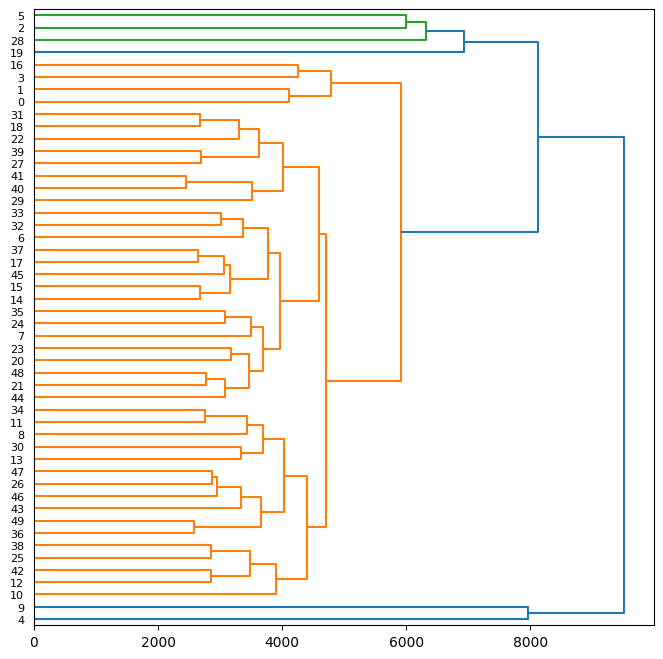

In [49]:
Z = linkage(squareform(D), method="complete")
plt.figure(figsize=(8, 8))
dendrogram(Z, orientation="right")
plt.show()

In [2]:
D.shape

NameError: name 'D' is not defined

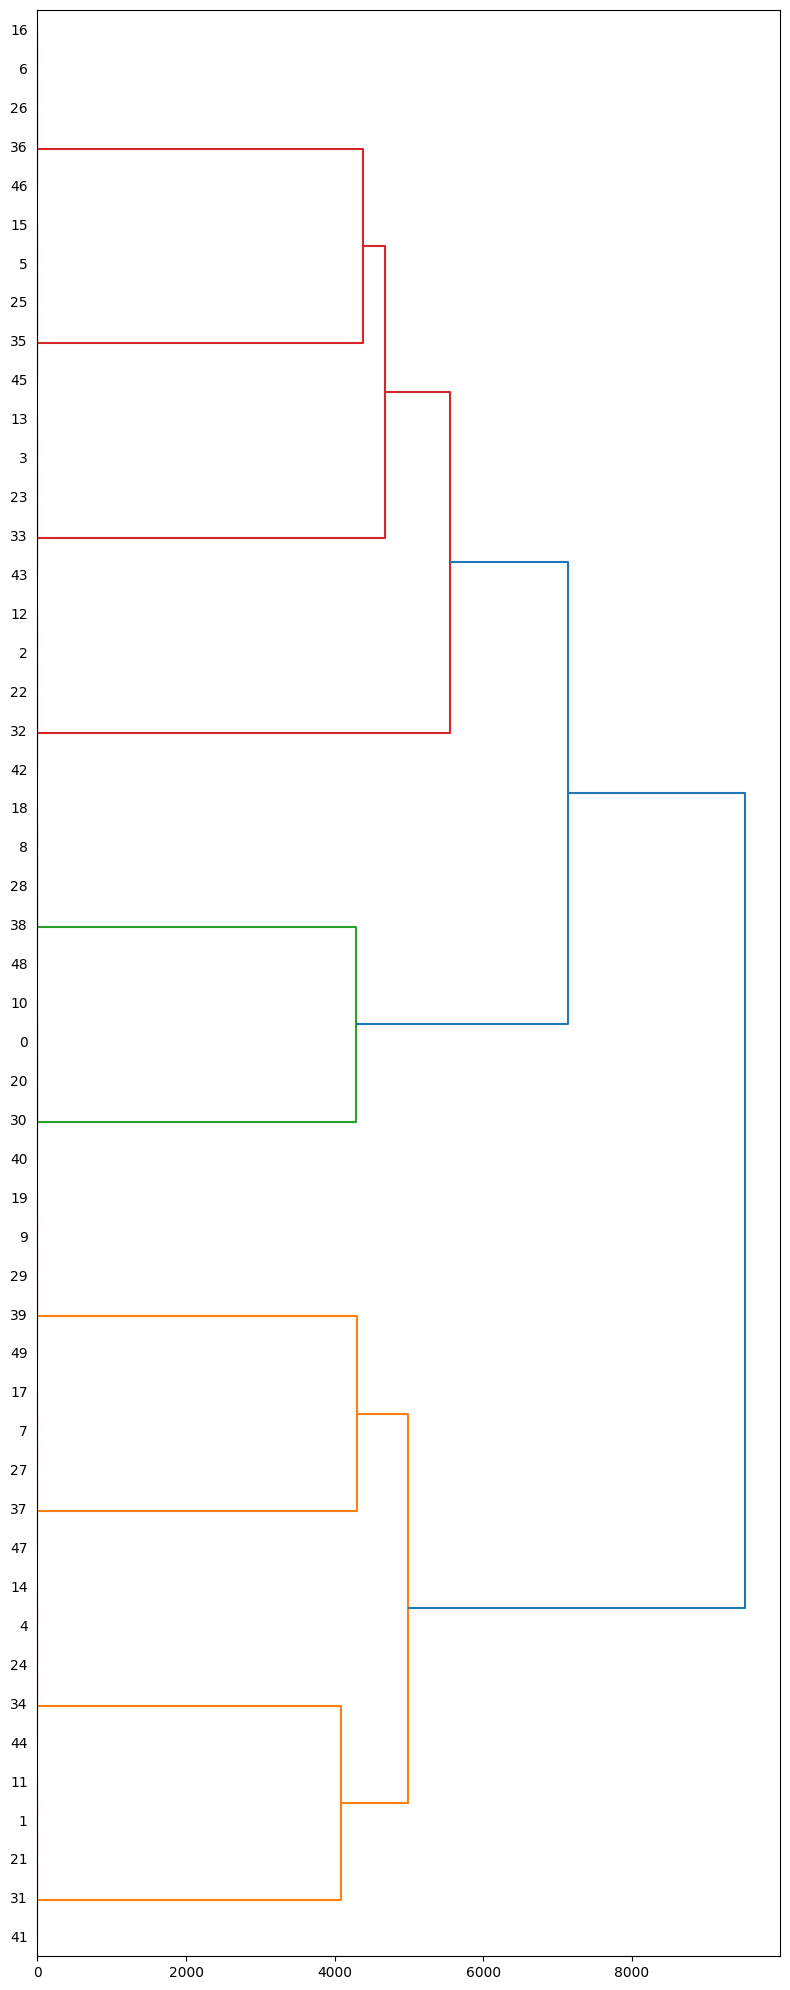

In [36]:
Z = linkage(squareform(D), method="complete")

plt.figure(figsize=(8, len(D) * 0.4))  # Scale height based on number of obs

dendrogram(
    Z,
    orientation="right",
    labels=[str(i) for i in range(len(D))],  # Optional: custom labels
    leaf_rotation=0,
    leaf_font_size=10,
    no_plot=False,
)

plt.tight_layout()
plt.show()

In [41]:
D

array([[    0.        ,  8224.87511251, 12617.63545683, ...,
            0.        ,     0.        ,     0.        ],
       [ 8224.87511251,     0.        ,  8696.10741225, ...,
            0.        ,     0.        ,     0.        ],
       [12617.63545683,  8696.10741225,     0.        , ...,
            0.        ,     0.        ,     0.        ],
       ...,
       [    0.        ,     0.        ,     0.        , ...,
            0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        , ...,
            0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        , ...,
            0.        ,     0.        ,     0.        ]])

In [11]:
len(indices)

45

In [10]:
len(results)

45

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from obspy import Stream, Trace
from scipy.signal import spectrogram as scipy_spectrogram


def plot_waveforms_and_spectrograms(
    data, wlen=10, log=False, figsize=(12, 4), cmap="viridis", save_path=None
):
    # Normalize input
    if isinstance(data, Trace):
        data = Stream(traces=[data])
    elif not isinstance(data, Stream):
        raise TypeError("Input must be an ObsPy Stream or Trace.")

    n = len(data)

    # Compute all spectrograms and find global min/max
    spectrograms = []
    global_min, global_max = np.inf, -np.inf

    for tr in data:
        fs = tr.stats.sampling_rate
        nperseg = int(wlen * fs)
        f, t, Sxx = scipy_spectrogram(tr.data, fs=fs, nperseg=nperseg)
        if log:
            Sxx = 10 * np.log10(Sxx + 1e-10)
        spectrograms.append((f, t, Sxx))
        global_min = min(global_min, Sxx.min())
        global_max = max(global_max, Sxx.max())

    # Create subplots (always 2 columns: waveform + spectrogram)
    fig, axes = plt.subplots(n, 2, figsize=(figsize[0], figsize[1] * n))

    # Normalize axes to always be 2D array-like
    if n == 1:
        axes = [axes]  # single row of 2 axes -> wrap in list

    for i, tr in enumerate(data):
        ax_wave, ax_spec = axes[i]

        # Plot waveform
        times = tr.times()
        ax_wave.plot(times, tr.data, "k")
        ax_wave.set_title(f"{tr.id} — {tr.stats.starttime.date}")
        for label in ax_wave.get_xticklabels():
            label.set_rotation(30)
            label.set_horizontalalignment("right")

        # Plot spectrogram with fixed color scale
        f, t, Sxx = spectrograms[i]
        im = ax_spec.pcolormesh(
            t, f, Sxx, shading="gouraud", cmap=cmap, vmin=global_min, vmax=global_max
        )
        ax_spec.set_ylabel("Frequency [Hz]")
        ax_spec.set_xlabel("Time [s]")
        ax_spec.set_title(f"{tr.id}")

    # Shared colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label="Power")

    # Adjust layout
    fig.subplots_adjust(right=0.9, hspace=0.5)

    if save_path:
        fig.savefig(save_path)
        print(f"Saved to {save_path}")

    plt.show()
    return fig

In [20]:
flows = preproc_flow_annotations(
    pd.read_csv("../catalogs/XP/flow_catalog.csv", index_col=0)
)
confirmed_FP = preproc_flow_annotations(pd.read_csv("../catalogs/XP/confirmed_FP.csv"))
to_confirm = preproc_flow_annotations(pd.read_csv("../catalogs/XP/to_confirm.csv"))

remove_dict = {}
for station in ["ILL11", "ILL12", "ILL13", "ILL14", "ILL16", "ILL17", "ILL18"]:
    remove_dict[station] = pd.concat(
        [
            confirmed_FP[confirmed_FP["station"] == station].iloc[:, [0, 1, 2, 5]],
            to_confirm[to_confirm["station"] == station],
        ]
    ).reset_index(drop=True)

In [21]:
stations = ["ILL11", "ILL12", "ILL13", "ILL18"]
if_detections = {}
sta_lta_detections = {}
dtw_detections = {}

for station in stations:
    if_detections[station] = pd.read_csv(
        f"../output/XP/if/detections/{station}.csv", index_col=0
    )
    sta_lta_detections[station] = pd.read_csv(
        f"../output/XP/sta_lta/detections/{station}.csv", index_col=0
    )

stations = ["ILL11", "ILL12", "ILL13", "ILL14", "ILL16", "ILL17", "ILL18"]

for station in stations:
    dtw_detections[station] = pd.read_csv(
        f"../output/XP/if_dtw/detections/{station}.csv", index_col=0
    )

In [22]:
IF_FP = {}
STA_LTA_FP = {}
DTW_FP = {}
for station in ["ILL11", "ILL12", "ILL13", "ILL18"]:
    _, _, station_flows = extract_split_flows(flows, station, 2018, 2022)
    IF_FP[station] = find_fp_fn(if_detections[station], station_flows)[0].reset_index(
        drop=True
    )
    STA_LTA_FP[station] = find_fp_fn(sta_lta_detections[station], station_flows)[
        0
    ].reset_index(drop=True)

for station in ["ILL11", "ILL12", "ILL13", "ILL14", "ILL16", "ILL17", "ILL18"]:
    _, _, station_flows = extract_split_flows(flows, station, 2018, 2022)
    DTW_FP[station] = find_fp_fn(dtw_detections[station], station_flows)[0].reset_index(
        drop=True
    )

In [23]:
if_unconfirmed = {}

for station in ["ILL11", "ILL12", "ILL13", "ILL18"]:
    FP = find_fp_fn(IF_FP[station], remove_dict[station])[0]

    if FP is np.nan:
        continue

    if len(FP) == 0:
        continue

    if_unconfirmed[station] = FP.reset_index(drop=True)

In [24]:
sta_lta_unconfirmed = {}

for station in ["ILL11", "ILL12", "ILL13", "ILL18"]:
    FP = find_fp_fn(STA_LTA_FP[station], remove_dict[station])[0]

    if FP is np.nan:
        continue

    if len(FP) == 0:
        continue

    sta_lta_unconfirmed[station] = FP.reset_index(drop=True)

In [25]:
dtw_unconfirmed = {}
for station in ["ILL11", "ILL12", "ILL13", "ILL14", "ILL16", "ILL17", "ILL18"]:
    FP = find_fp_fn(DTW_FP[station], remove_dict[station])[0]

    if FP is np.nan:
        continue

    if len(FP) == 0:
        continue

    dtw_unconfirmed[station] = FP.reset_index(drop=True)

In [26]:
for station in if_unconfirmed:
    print(station, if_unconfirmed[station])

In [27]:
for station in sta_lta_unconfirmed:
    print(station, sta_lta_unconfirmed[station])

In [28]:
for station in dtw_unconfirmed:
    print(station, dtw_unconfirmed[station])

In [158]:
# ILL18: 2021-04-21T09:10:02.560000Z  2021-04-21T10:01:53.500000Z ~ difficult one since only ILL18 is active...perhaps activity...check for earthquakes


In [159]:
# seg = sta_lta_unconfirmed["ILL18"].iloc[0]
# seg = dtw_unconfirmed["ILL14"].iloc[0]
# seg = dtw_unconfirmed["ILL17"].iloc[0]
# seg = FP.iloc[29]
# # np.where(FP["Labels"] == "HEL")
# #seg = ILL17_flows.iloc[2]
# #np.where(FP["Labels"] == "MS")
# np.where(FP["Labels"] == "AN")

In [ ]:
# dt = str(seg["start"])[:10]
# time_b = timedelta(seconds=5*60)
# time_t = timedelta(seconds=0*60)

# streams = obspy.Stream()
# t0 = obspy.UTCDateTime(seg["start"]) - time_b
# t1 = obspy.UTCDateTime(seg["stop"]) + time_t
# #t1 = obspy.UTCDateTime(seg["start"]) + time_b

# # t0 = obspy.UTCDateTime("2019-04-06T08:58:03.910000Z")
# # # t0 = obspy.UTCDateTime("2021-08-16T11:15:00.390000Z")
# # t1 = obspy.UTCDateTime("2021-04-11T11:15:44.420000Z")

# for station in ["ILL11","ILL12","ILL13","ILL14","ILL15","ILL16","ILL17","ILL18"]:
#     channel = "EHZ.D"

#     if station == "ILL11":
#         channel = "HHZ.D"
#     try:
#         paths = find_paths("XP", station, channel, 2018, 2022)
#         p = find_date_in_strings(paths, dt)[0]
#         st = obspy.read(p)
#         st = remove_overlaps(st)
#         st = remove_duplicate_traces(st)
#         preproc_stream(st)
#         st.trim(t0, t1)
#         #streams += st
#         streams += normalize_stream_to_unit_range(st)

#     except:
#         continue



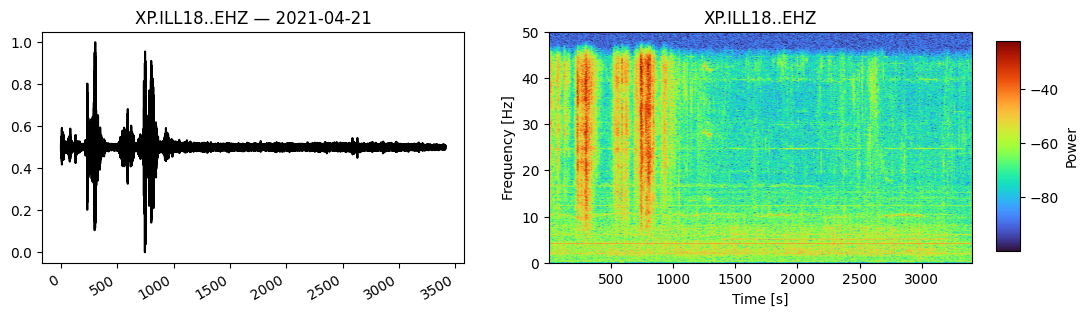

In [ ]:
# fig =plot_waveforms_and_spectrograms(streams,figsize=(12, 3),log=True,cmap="turbo")